# Task 3: Evaluate Deforestation through Bitemporal Change Detection

In this final task we quantify deforestation in São Félix do Xingu based on bitemporal satellite observations. We use the Sentinel-2 tile T22MCU previously downloaded and visualized in Task 1, and the CNN-based segmentation model from Task 2 for comparison. Our objective is to measure both absolute and relative forest loss between 2018 and 2024. In this task we perform quantitative change detection at the patch level using two complementary approaches:

- **NDVI differencing**
- **CNN segmentation differencing**

The combined evaluation enables us to assess the agreement between physical indices and data-driven model outputs while identifying specific strengths and limitations of both approaches. 

We focus on tile **T22MCU** which covers one of the most deforested sectors in the municipality and shows strong spatial variability in canopy loss. 

**Important Note**

If you were not able to complete Task 1 or 2, we provide a preprocessed version of the tile and a simple pretrained CNN model for this task. Please use these resources if necessary.
The model can be loaded with `model = torch.jit.load("backup_model.pt")`




### Imports
These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)
root

WindowsPath('C:/dev/TU/IPEO/ipl4eo_miniproject_2025')

In [2]:
from abc import ABC, abstractmethod
from pathlib import Path
from typing import Dict, Tuple, Optional
from dataclasses import dataclass, field
import numpy as np
import torchvision.transforms as transforms
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import sys

from scipy.ndimage import zoom
import random

In [3]:
# Additionally, import util functions that where copied from the lab notebooks
import labUtils as labUtils

## 3.1 Patch Extraction and Preprocessing

- Load the tile
  
- Perform bilinear interpolation of 20m bands to 10m spatial resolution for all 20m bands of the tile (You could use [Rasterio](https://rasterio.readthedocs.io/en/stable/topics/resampling.html))

- Divide the tile into non-overlapping patches of size **120 x 120 pixels**.


In [4]:
# ---------------
# normalization

global_mean = np.array([438.37207031, 614.05566406, 588.40960693, 2193.29199219, 942.84332275, 1769.93164062, 2049.55151367, 1568.22680664, 997.73248291, 2235.55664062])
global_std  = np.array([607.02685547, 603.29681396, 684.56884766, 1369.3717041, 738.43267822, 1100.45605469, 1275.80541992, 1070.16125488, 813.52764893, 1356.54406738])

# same as in task_2 notebook but for numpy arrays
def normalize_s2_image(image_array):
    image_array = image_array.transpose(2, 0, 1)

    # reflectance clipping
    image_array = np.clip(image_array, 0, 5000) / 5000.0

    # using the provided means and std for the "global" normalization
    mean = global_mean / 5000
    std  = global_std / 5000
    norm = (image_array - mean[:, None, None]) / std[:, None, None]
    
    return norm.transpose(1, 2, 0)


def denormalize_s2_image(norm_tensor):
    mean = global_mean
    std  = global_std
    return norm_tensor * std[:, None, None] + mean[:, None, None]

In [5]:
# Note:
# I reversed the order of interpolation and tile division to make the code more memory efficient
# Also I added a "LazyPatchList" to allow lazy loading on the patches because loading all patches/tiles at once exceeded my laptops memory

def upsample_patch(patch, scale_factor=2):
    return zoom(patch, zoom=(scale_factor, scale_factor, 1), order=1).astype(np.float32)


def get_combined_bands(tile_reader, bands, normalize=True):
    bands_data = []
    
    for band_name in bands:
        tile = tile_reader.read_band(band_name).astype(np.float32)
        bands_data.append(tile)
    
    stacked = np.stack(bands_data, axis=-1)
    return stacked

    
# ------------
# For the patch sampling i created this class to enable lazy loading since my laptop was not able to handle all the data at once
class LazyPatchList:
    def __init__(self, tile_20m, tile_10m, patch_size, scale_factor=2):
        self.tile_20m = tile_20m
        self.tile_10m = tile_10m
        self.ph, self.pw = patch_size
        self.scale_factor = scale_factor

        self.h, self.w, self.c = tile_10m.shape
        self.n_rows = self.h // self.ph
        self.n_cols = self.w // self.pw
        self.total = int(self.n_rows * self.n_cols)

    def get_patch(self, tile, row, col, pw, ph):
        y = row * ph
        x = col * pw
        return tile[y:y + ph, x:x + pw, :]

    def __len__(self):
        return self.total

    def __getitem__(self, idx):
        if idx < 0 or idx >= self.total:
            raise IndexError("Index out of range")

        # TODO Row and patch false?
        row = idx // self.n_cols
        col = idx % self.n_cols
        
        # usample the 20m patch
        patch_20m = self.get_patch(self.tile_20m, row, col, self.pw // 2, self.ph // 2) # // 2 because of later upsampling
        patch_20m = upsample_patch(patch_20m)

        # get the 10m patch
        patch_10m = self.get_patch(self.tile_10m, row, col, self.pw, self.ph)

        # note:
        # at first I stacked the patch20m and the patch10m directley,
        # but than i ralized that the order is different according to sentinel 2's specification

        """
        full_bands = np.stack([
            patch_10m[:, :, 0],
            patch_10m[:, :, 1],
            patch_10m[:, :, 2],
            patch_20m[:, :, 0],
            patch_20m[:, :, 1],
            patch_20m[:, :, 2],
            patch_10m[:, :, 3],
            patch_20m[:, :, 3],
            patch_20m[:, :, 4],
            patch_20m[:, :, 5]
        ], axis=2)
        """
        full_bands = np.stack([
            patch_10m[:, :, 0],
            patch_10m[:, :, 1],
            patch_10m[:, :, 2],
            patch_10m[:, :, 3],
            patch_20m[:, :, 0],
            patch_20m[:, :, 1],
            patch_20m[:, :, 2],
            patch_20m[:, :, 3],
            patch_20m[:, :, 4],
            patch_20m[:, :, 5]
        ], axis=2)
        
        #print(np.shape(full_bands))
        return normalize_s2_image(full_bands)
        #return labUtils.quant_norm_data(full_bands)


In [6]:
# ------------------
# Processing tiles

tile_reader_2018 = labUtils.S2TileReader(Path("data/2018/"))
tile_reader_2024 = labUtils.S2TileReader(Path("data/2024/"))

# Read 20m bands (upsampled, normalized)
img_2018_20m = get_combined_bands(
    tile_reader_2018,
    ["B05_20m", "B06_20m", "B07_20m", "B8A_20m", "B11_20m", "B12_20m"],
    #normalize=True
)
print("Loaded img_2018_20m")

#img_2024_20m = get_combined_bands(
#    tile_reader_2024,
#    ["B05_20m", "B06_20m", "B07_20m", "B8A_20m", "B11_20m", "B12_20m"],
#    #normalize=True
#)
#print("Loaded img_2024_20m")

img_2018_10m = get_combined_bands(
    tile_reader_2018,
    ["B02_10m", "B03_10m", "B04_10m", "B08_10m"],
    #normalize=False
)
print("Loaded img_2018_10m")

#img_2024_10m = get_combined_bands(
#    tile_reader_2024,
#    ["B02_10m", "B03_10m", "B04_10m", "B08_10m"],
#    #normalize=False
#)
#print("Loaded img_2018_10m")


print("2018 20m stacked shape:", np.shape(img_2018_20m))
print("2018 10m stacked shape:", np.shape(img_2018_10m))

10 images found in data\2018
10 images found in data\2024
Loaded img_2018_20m
Loaded img_2018_10m
2018 20m stacked shape: (5490, 5490, 6)
2018 10m stacked shape: (10980, 10980, 4)


In [7]:
# ------------------
# Extract patches as (as lazy generators)


patches_2018 = LazyPatchList(img_2018_20m, img_2018_10m, patch_size=(120, 120))

#patches_2024_20m = LazyPatchList(img_2024_20m, patch_size=(120, 120), upsample=True)
#patches_2024_10m = LazyPatchList(img_2024_10m, patch_size=(120, 120), upsample=False)
#patches_2024 = np.stack([patches_2024_10m, patches_2024_20m], axis=-1,)

print(f"Amount of patches: {len(patches_2018)}")

example_patch = patches_2018[15]
print(example_patch.shape)

print("Patch Value Ranges")
print("Mask value ranges")
print(example_patch.min().item(), example_patch.max().item(), example_patch.mean().item(), example_patch.std().item())

Amount of patches: 8281
(120, 120, 10)
Patch Value Ranges
Mask value ranges
-0.6384911761063293 3.1385627325134604 1.119889529475201 0.6712466657639282


## 3.2 Change detection
### 3.2.1 NDVI and CNN Mask Calculation

For each extracted patch compute:

 a. NDVI
 
 b. CNN Mask
    - Apply the CNN segmentation model from Task 2 to each patch. (**Note:** don't forget to preprocess)
    
To convert it into a binary mask, find a good threshhold. Argue your choice for the NDVI and CNN in a short paragraph.

### 3.2.2 Change Detection and Forest Loss Computation

For both NDVI and CNN masks compute for the full tile (all patches):

- **Percentage loss:**  
  percentage_loss = 100 * (forest_pixels_2018 - forest_pixels_2024) / forest_pixels_2018

- **Absolute loss (m²):**  
  absolute_loss = (forest_pixels_2018 - forest_pixels_2024) * 100

where `forest_pixels_2018` and `forest_pixels_2024` are the number of forest pixels in 2018 and 2024, respectively. Each pixel represents 100 m² (10m resolution).


(120, 120, 3)


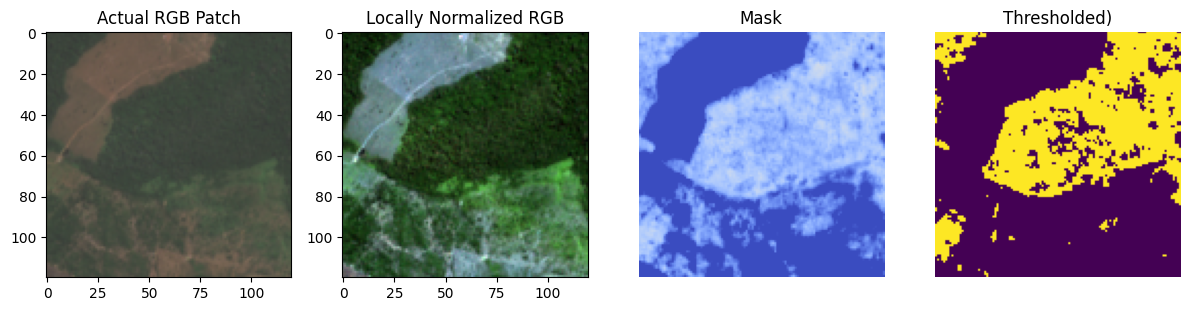

In [20]:
# -----------------
# plot utils


def plot_patch_and_maps(patch, map1, map2):
    actual_rgb = np.transpose(patch, (2, 0, 1))
    actual_rgb = denormalize_s2_image(actual_rgb)
    actual_rgb = actual_rgb[np.array((2, 1, 0))] / 5000
    actual_rgb = np.transpose(actual_rgb, (1, 2, 0))

    local_normalized_rgb = patch[:, : , np.array((0,1,2))]
    print(np.shape(local_normalized_rgb))
    rgb_norm = labUtils.normalize_rgb(local_normalized_rgb)

    plt.figure(figsize=(12, 3))
    
    plt.subplot(1, 4, 1)
    plt.imshow(actual_rgb)
    plt.title("Actual RGB Patch")
    plt.axis('on')

    plt.subplot(1, 4, 2)
    plt.imshow(rgb_norm)
    plt.title("Locally Normalized RGB")
    plt.axis('on')

    plt.subplot(1, 4, 3)
    plt.imshow(map1, cmap='coolwarm', vmin=0, vmax=1)
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(map2, cmap='viridis', vmin=0, vmax=1)
    plt.title("Thresholded)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# ------------------
# NVDI calculation

def compute_ndvi(patch, binarize=False, threshold=0.25):
    """
    NIR is band index 3 (B8A_20m)
    RED is band index 1 (B05_20m)
    """
    nir = patch[:, :, 6].astype(np.float32)
    red = patch[:, :, 2].astype(np.float32)

    ndvi = (nir - red) / (nir + red + 1e-6)  # Add epsilon to avoid division by zero

    if binarize:
        ndvi = (ndvi > threshold).astype(np.uint8)
    return np.clip(ndvi, -1, 1) 

# --------------------
# Show some samples for visualization

patch_id = 4900
patch_2018 = patches_2018[patch_id]
plot_patch_and_maps(patch_2018, compute_ndvi(patch_2018), compute_ndvi(patch_2018, binarize=True))

patch orignal shape: (120, 120, 10)
INPUT
tensor(-0.5859) tensor(4.9196) torch.Size([1, 10, 120, 120])
input shape: torch.Size([1, 10, 120, 120])
output shape: torch.Size([1, 2, 120, 120])
prediction of first pixel: tensor([ 2.9864, -2.5259])
torch.Size([120, 120])
(120, 120, 3)


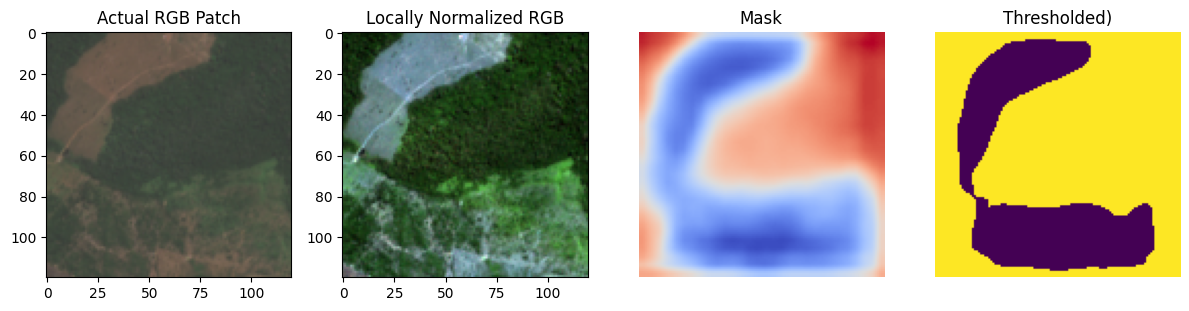

In [21]:
# --------------------
# CNN Model Prediction
# TODO use my own model --> add an export function to it

cnn_model = torch.jit.load(root / "data/fcresnet_ehrenhoefer_v7_skipconnections.pt")
#cnn_model = torch.jit.load(root / "data/backup_model.pt")
cnn_model.eval() 

def get_cnn_model_prediction(patch, binarize=False, threshold=0.5):
    print(f"patch orignal shape: {np.shape(patch)}")
    input = np.transpose(patch, (2, 0, 1))
    input = torch.tensor(input, dtype=torch.float32)
    input = input.unsqueeze(0)
    print("INPUT")
    print(input.min(), input.max(), np.shape(input))
    print(f"input shape: {np.shape(input)}")
    with torch.no_grad():
        preds = cnn_model(input)
        print(f"output shape: {np.shape(preds)}")
        #print(f"output min / max: {preds.min()}, {preds.max()}")
        print(f"prediction of first pixel: {preds[0, :, 119, 119]}")

    #mask_pred = torch.sigmoid(preds)
    #mask_pred = preds.squeeze(0)
    probs = torch.softmax(preds, dim=1)
    mask_pred = torch.argmax(probs, dim=1)

    non_forest_scores = preds[0, 0, :, :]
    forest_scores = preds[0, 1, :, :]
    forest_certainty = forest_scores - non_forest_scores

    return mask_pred, forest_certainty

# -------------------
# Also show the re3sults of the CNN Model
patch_id = 4900#4900
patch_2018 = patches_2018[patch_id]
mask_preds, forest_scores = get_cnn_model_prediction(patch_2018)

mask_image = np.transpose(mask_preds, (1, 2, 0))

normalized_forest_scores = (forest_scores - forest_scores.min()) / (forest_scores.max() - forest_scores.min())

print(np.shape(forest_scores))
plot_patch_and_maps(patch_2018, normalized_forest_scores, normalized_forest_scores > 0.25)

**TODO:** Describe the results in a few paragraphs.

## 3.3 Extensive Qualitative Analysis

Select six representative patches:

- Two patches with high loss.
- Two patches with minimal or no loss.
- Two patches with interesting discrepancies between methods.

For each patch plot:

- RGB composite for 2018 and 2024.
- CNN mask for 2018 and 2024.
- NDVI mask for 2018 and 2024.

Annotate each visualization with the computed percentage loss for both NDVI and CNN.



In [ ]:
# Here go some plots

## 3.4 Method Comparison and Interpretation

Write a detailed qualitative evaluation (~500 words) discussing:

- Describe your plots.
- Which method performed more robustly across varying conditions. Why?
- Sensitivity to atmospheric noise, and classification errors.
- Advantages and limitations of both approaches.
- Possible improvements of both methods.
- Which method you would recommend for systematic deforestation assessment.
- Further remarks/ observations.



**TODO:** Describe the results.